In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.ticker import LogLocator

### Degree Distribution

In [37]:

summary_path = "../scripts/final_draft_100_degree_distribution_stats.csv"
df = pd.read_csv(summary_path)

In [38]:
std_col = "param_0"
alpha_col = "param_1"

df[alpha_col] = df[alpha_col].astype(float)
df[std_col] = df[std_col].astype(float)

std_values = np.sort(df[std_col].unique())

In [39]:
features = ["mean", "std", "p10", "p25", "median", "p75", "p90"]
empirical_values = [126.1, 97, 34, 52, 97, 185, 236]
y_labels = [
    "Mean degree",
    "Standard deviation (of degree distribution)",
    r"$10^{\mathrm{th}}$ percentile degree",
    r"$25^{\mathrm{th}}$ percentile degree",
    "Median degree",
    r"$75^{\mathrm{th}}$ percentile degree",
    r"$90^{\mathrm{th}}$ percentile degree",
]

Plotting mean vs alpha


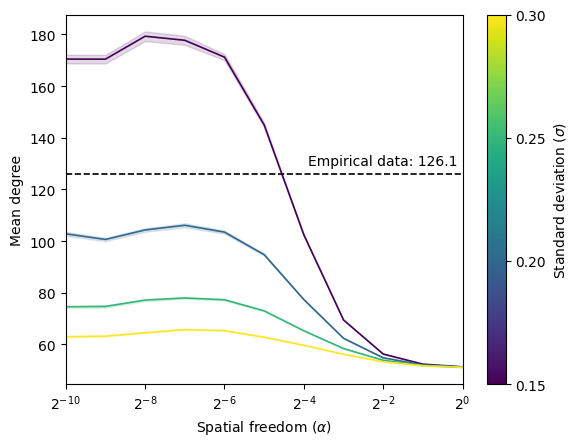

Plotting std vs alpha


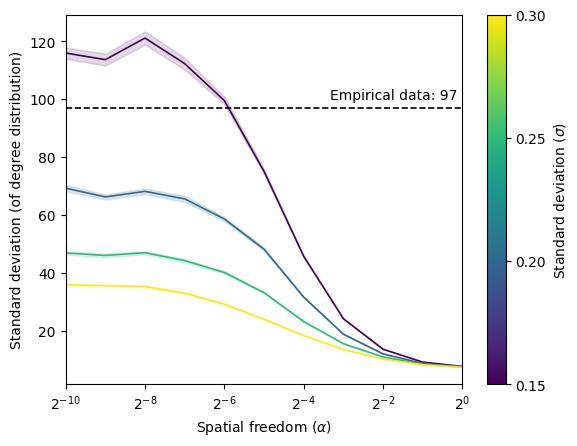

Plotting p10 vs alpha


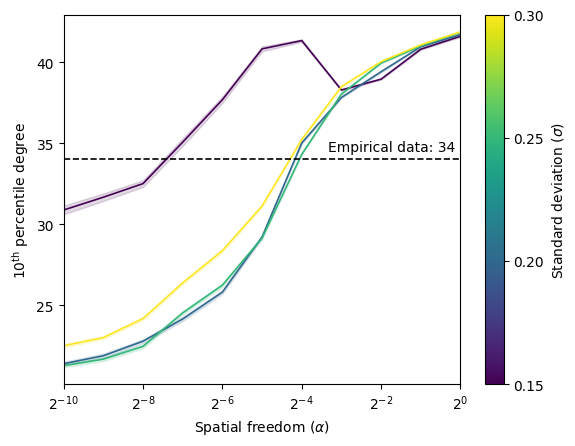

Plotting p25 vs alpha


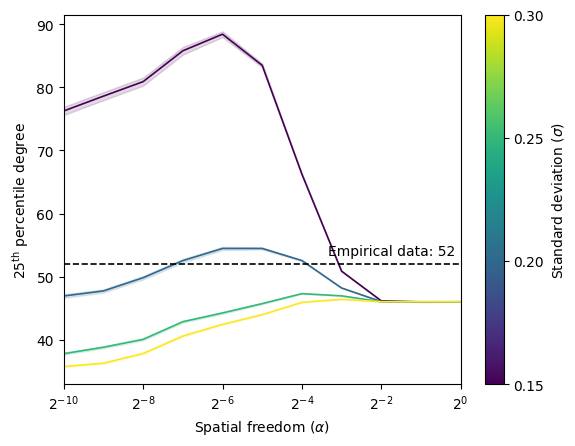

Plotting median vs alpha


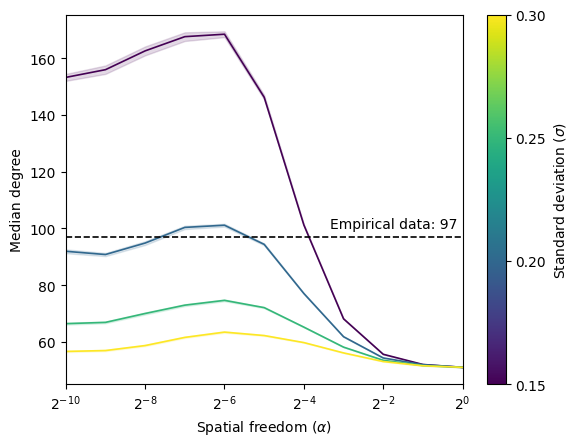

Plotting p75 vs alpha


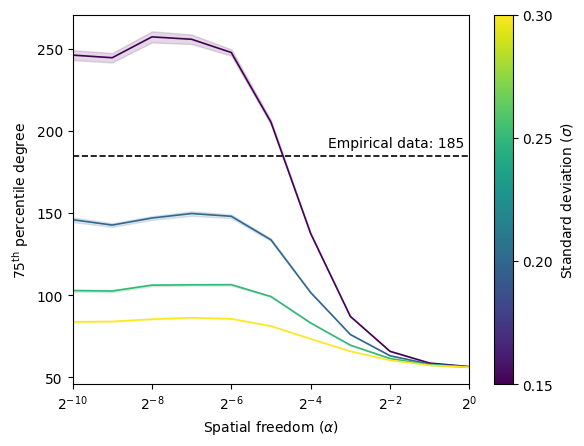

Plotting p90 vs alpha


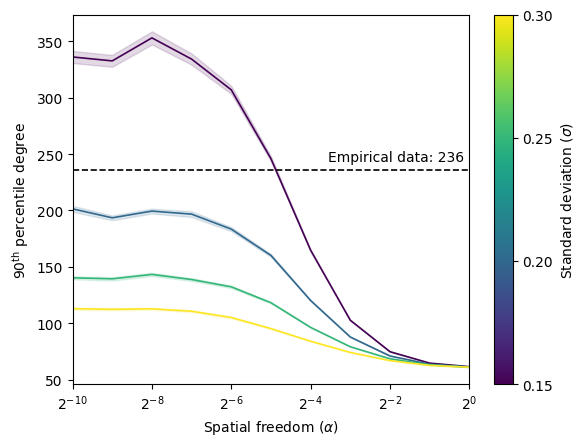

In [40]:
cmap = plt.cm.viridis
norm = Normalize(
    vmin=std_values.min(),
    vmax=std_values.max(),
)

tick_exponents = np.arange(-10, 1, 2)
alpha_ticks = 2.0 ** tick_exponents

for feature, empirical_value, y_label in zip(
    features,
    empirical_values,
    y_labels,
):
    se_col = f"se_{feature}"

    if feature not in df.columns:
        raise KeyError(
            f"Column '{feature}' is missing from the CSV."
        )

    if se_col not in df.columns:
        raise KeyError(
            f"Column '{se_col}' is missing from the CSV."
        )

    print(f"Plotting {feature} vs alpha")

    fig, ax = plt.subplots()

    for std in std_values:
        sub = (
            df[df[std_col] == std]
            .sort_values(alpha_col)
        )

        alphas = sub[alpha_col].to_numpy(dtype=float)
        values = sub[feature].to_numpy(dtype=float)
        ses = sub[se_col].to_numpy(dtype=float)

        color = cmap(norm(std))

        lower = values - ses
        upper = values + ses

        # Required because the y-axis is logarithmic.
        valid_line = (
            np.isfinite(alphas)
            & np.isfinite(values)
            & (alphas > 0)
            & (values > 0)
        )

        ax.plot(
            alphas[valid_line],
            values[valid_line],
            color=color,
            linewidth=1.2,
        )

        # fill_between does not support non-positive values on a log axis.
        lower[lower <= 0] = np.nan
        upper[upper <= 0] = np.nan

        ax.fill_between(
            alphas,
            lower,
            upper,
            color=color,
            alpha=0.15,
        )

    sm = cm.ScalarMappable(
        cmap=cmap,
        norm=norm,
    )
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label(r"Standard deviation ($\sigma$)")
    cbar.set_ticks(std_values)
    cbar.set_ticklabels([
        f"{std:.2f}"
        for std in std_values
    ])

    # Base-2 logarithmic alpha axis.
    ax.set_xscale("log", base=2)
    ax.set_xlim(2**-10, 1)
    ax.set_xticks(alpha_ticks)
    ax.set_xticklabels([
        rf"$2^{{{exponent}}}$"
        for exponent in tick_exponents
    ])

    # Empirical reference.
    ax.axhline(
        empirical_value,
        color="black",
        linestyle="--",
        linewidth=1.2,
    )

    ax.annotate(
        f"Empirical data: {empirical_value:g}",
        xy=(1, empirical_value),
        xytext=(-4, 4),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=10,
    )

    ax.set_xlabel(r"Spatial freedom ($\alpha$)")
    ax.set_ylabel(y_label)

    fig.savefig(
        f"fitting_degree_{feature}_vs_alpha_by_std_100.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

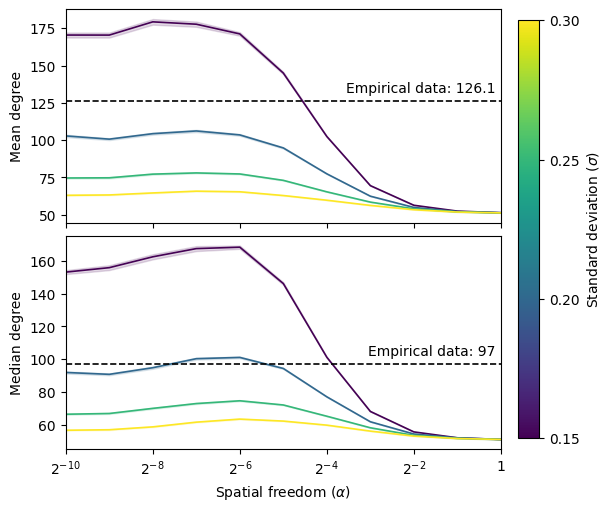

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize


std_col = "param_0"
alpha_col = "param_1"

df = df.copy()

df[std_col] = df[std_col].astype(float)
df[alpha_col] = df[alpha_col].astype(float)

std_values = np.sort(df[std_col].unique())

cmap = plt.cm.viridis
norm = Normalize(
    vmin=std_values.min(),
    vmax=std_values.max(),
)

tick_exponents = np.arange(-10, 1, 2)
alpha_ticks = 2.0 ** tick_exponents

plot_features = [
    "mean",
    "median",
]

plot_se_columns = [
    "se_mean",
    "se_median",
]

plot_labels = [
    "Mean degree",
    "Median degree",
]

empirical_values = [
    126.1,
    97,
]

for column in plot_features + plot_se_columns:
    if column not in df.columns:
        raise KeyError(
            f"Column '{column}' is missing from the CSV."
        )

fig, axes = plt.subplots(
    2,
    1,
    figsize=(6, 5),
    sharex=True,
    constrained_layout=True,
)

for (
    ax,
    feature,
    se_col,
    y_label,
    empirical_value,
) in zip(
    axes,
    plot_features,
    plot_se_columns,
    plot_labels,
    empirical_values,
):
    for std in std_values:
        sub = (
            df[df[std_col] == std]
            .sort_values(alpha_col)
        )

        alphas = sub[alpha_col].to_numpy(dtype=float)
        values = sub[feature].to_numpy(dtype=float)
        ses = sub[se_col].to_numpy(dtype=float)

        color = cmap(norm(std))

        valid_line = (
            np.isfinite(alphas)
            & np.isfinite(values)
            & (alphas > 0)
        )

        ax.plot(
            alphas[valid_line],
            values[valid_line],
            color=color,
            linewidth=1.2,
        )

        lower = values - ses
        upper = values + ses

        valid_band = (
            np.isfinite(alphas)
            & np.isfinite(lower)
            & np.isfinite(upper)
            & (alphas > 0)
        )

        ax.fill_between(
            alphas[valid_band],
            lower[valid_band],
            upper[valid_band],
            color=color,
            alpha=0.15,
        )

    ax.axhline(
        empirical_value,
        color="black",
        linestyle="--",
        linewidth=1.2,
    )

    ax.annotate(
        f"Empirical data: {empirical_value:g}",
        xy=(1, empirical_value),
        xytext=(-4, 4),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=10,
    )

    ax.set_ylabel(y_label)

# Shared base-2 logarithmic x-axis.
axes[-1].set_xscale("log", base=2)
axes[-1].set_xlim(2**-10, 1)
axes[-1].set_xticks(alpha_ticks)
axes[-1].set_xticklabels([
    "1" if exponent == 0 else rf"$2^{{{exponent}}}$"
    for exponent in tick_exponents
])
axes[-1].set_xlabel(r"Spatial freedom ($\alpha$)")

# Hide duplicate x tick labels on the upper subplot.
axes[0].tick_params(labelbottom=False)

# Shared colorbar on the right of both plots.
sm = cm.ScalarMappable(
    cmap=cmap,
    norm=norm,
)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes,
    location="right",
    pad=0.03,
    shrink=0.95,
)

cbar.set_label(r"Standard deviation ($\sigma$)")
cbar.set_ticks(std_values)
cbar.set_ticklabels([
    f"{std:.2f}"
    for std in std_values
])

fig.savefig(
    "fitting_mean_median_vs_alpha_by_std.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

### Average Alter Distance Distribution

In [42]:

summary_path = "../scripts/final_draft_100_avg_alter_dist_distribution_stats.csv"
df = pd.read_csv(summary_path)

In [43]:
std_col = "param_0"
alpha_col = "param_1"

df[alpha_col] = df[alpha_col].astype(float)
df[std_col] = df[std_col].astype(float)

std_values = np.sort(df[std_col].unique())

In [44]:
features = ["mean", "std", "p10", "p25", "median", "p75", "p90"]
empirical_values = [13.896, 14.220, 1.188, 4.107, 9.822, 19.024, 31.545]
#empirical_values = [val / 312 for val in empirical_values]
y_labels = [
    "Mean Average Alter Distance",
    "Standard Deviation (of Average Alter Distance Distribution)",
    r"$10^{\mathrm{th}}$ Percentile Average Alter Distance",
    r"$25^{\mathrm{th}}$ Percentile Average Alter Distance",
    "Median Average Alter Distance",
    r"$75^{\mathrm{th}}$ Percentile Average Alter Distance",
    r"$90^{\mathrm{th}}$ Percentile Average Alter Distance",
]

Plotting mean vs alpha


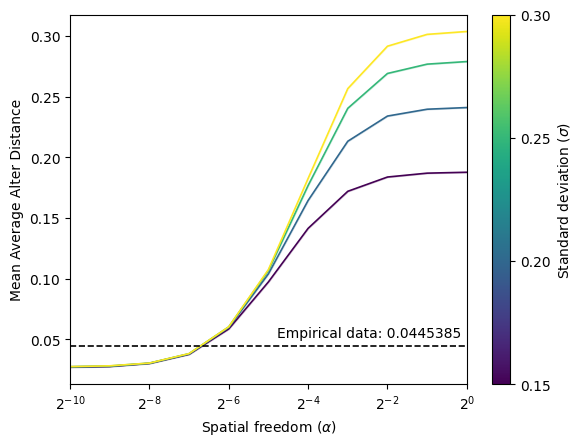

Plotting std vs alpha


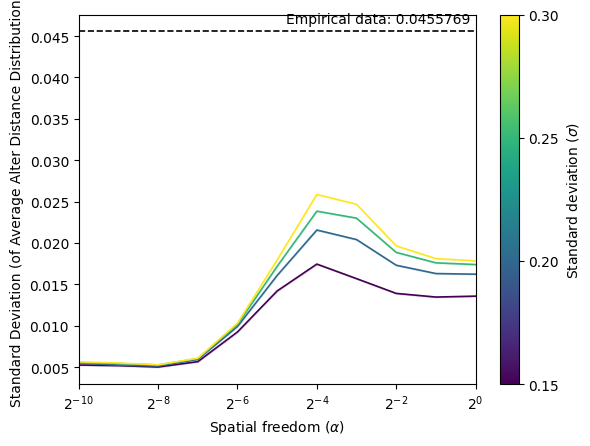

Plotting p10 vs alpha


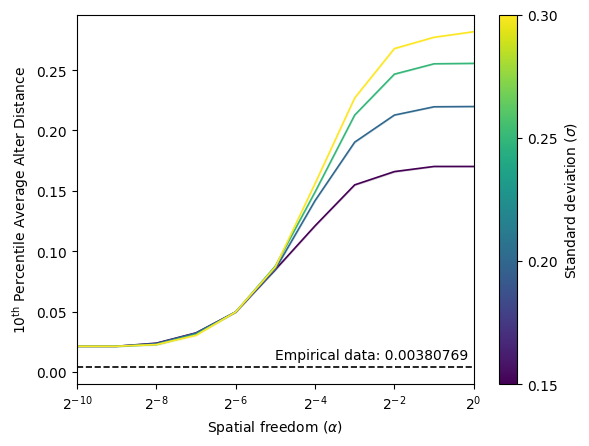

Plotting p25 vs alpha


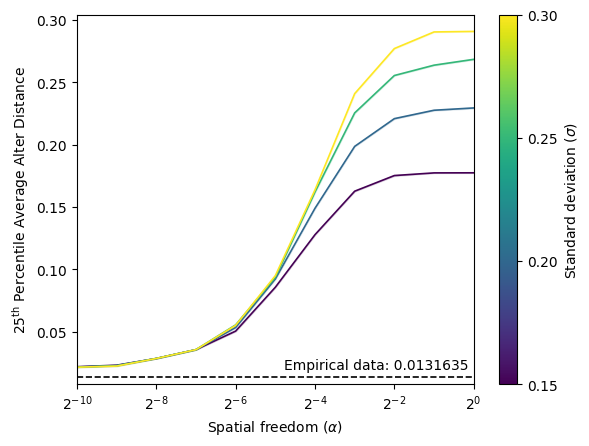

Plotting median vs alpha


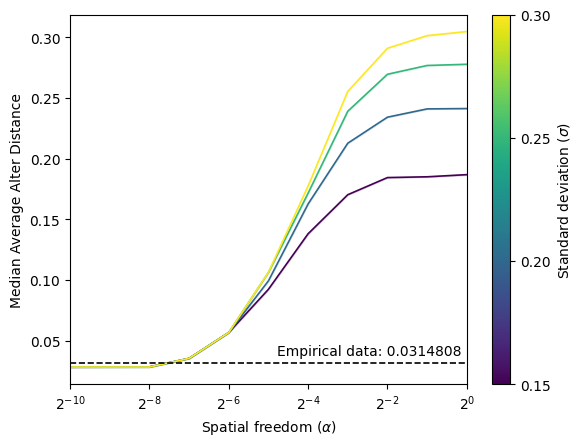

Plotting p75 vs alpha


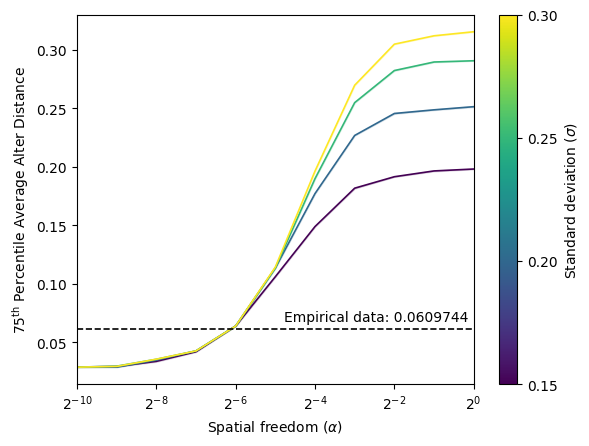

Plotting p90 vs alpha


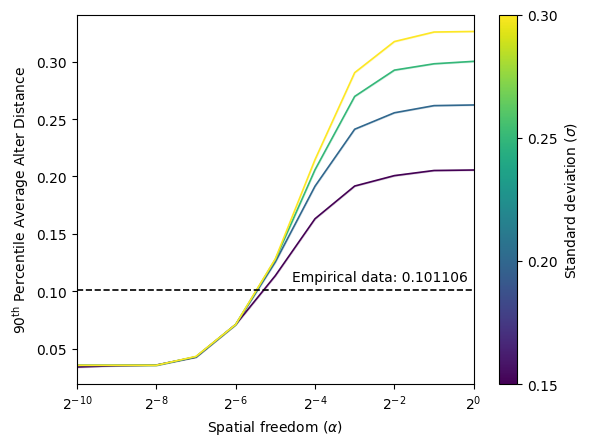

In [45]:
cmap = plt.cm.viridis
norm = Normalize(
    vmin=std_values.min(),
    vmax=std_values.max(),
)

tick_exponents = np.arange(-10, 1, 2)
alpha_ticks = 2.0 ** tick_exponents

for feature, empirical_value, y_label in zip(
    features,
    empirical_values,
    y_labels,
):
    se_col = f"se_{feature}"

    if feature not in df.columns:
        raise KeyError(
            f"Column '{feature}' is missing from the CSV."
        )

    if se_col not in df.columns:
        raise KeyError(
            f"Column '{se_col}' is missing from the CSV."
        )

    print(f"Plotting {feature} vs alpha")

    fig, ax = plt.subplots()

    for std in std_values:
        sub = (
            df[df[std_col] == std]
            .sort_values(alpha_col)
        )

        alphas = sub[alpha_col].to_numpy(dtype=float)
        values = (sub[feature]/1.41).to_numpy(dtype=float)
        ses = (sub[se_col]/1.41).to_numpy(dtype=float)

        color = cmap(norm(std))

        lower = values - ses
        upper = values + ses

        # Required because the y-axis is logarithmic.
        valid_line = (
            np.isfinite(alphas)
            & np.isfinite(values)
            & (alphas > 0)
            & (values > 0)
        )

        ax.plot(
            alphas[valid_line],
            values[valid_line],
            color=color,
            linewidth=1.2,
        )

        # fill_between does not support non-positive values on a log axis.
        lower[lower <= 0] = np.nan
        upper[upper <= 0] = np.nan

        ax.fill_between(
            alphas,
            lower,
            upper,
            color=color,
            alpha=0.15,
        )

    sm = cm.ScalarMappable(
        cmap=cmap,
        norm=norm,
    )
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label(r"Standard deviation ($\sigma$)")
    cbar.set_ticks(std_values)
    cbar.set_ticklabels([
        f"{std:.2f}"
        for std in std_values
    ])

    # Base-2 logarithmic alpha axis.
    ax.set_xscale("log", base=2)
    ax.set_xlim(2**-10, 1)
    ax.set_xticks(alpha_ticks)
    ax.set_xticklabels([
        rf"$2^{{{exponent}}}$"
        for exponent in tick_exponents
    ])

    # Empirical reference.
    ax.axhline(
        (empirical_value/312),
        color="black",
        linestyle="--",
        linewidth=1.2,
    )

    ax.annotate(
        f"Empirical data: {(empirical_value/312):g}",
        xy=(1, (empirical_value/312)),
        xytext=(-4, 4),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=10,
    )

    ax.set_xlabel(r"Spatial freedom ($\alpha$)")
    ax.set_ylabel(y_label)

    fig.savefig(
        f"fitting_avg_alter_dist_{feature}_vs_alpha_by_std_100.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)

### Clustering Distribution

In [46]:

summary_path = "../scripts/final_draft_100_local_clustering_distribution_stats.csv"
df = pd.read_csv(summary_path)

In [47]:
std_col = "param_0"
alpha_col = "param_1"

df[alpha_col] = df[alpha_col].astype(float)
df[std_col] = df[std_col].astype(float)

std_values = np.sort(df[std_col].unique())

In [48]:
features = ["mean", "std", "p10", "p25", "median", "p75", "p90"]
empirical_values = [0.406, 0.157, 0.243, 0.302, 0.378, 0.472, 0.601]
y_labels = [
    "Mean local clustering",
    "Standard deviation (of local clustering distribution)",
    r"$10^{\mathrm{th}}$ percentile local clustering",
    r"$25^{\mathrm{th}}$ percentile local clustering",
    "Median local clustering",
    r"$75^{\mathrm{th}}$ percentile local clustering",
    r"$90^{\mathrm{th}}$ percentile local clustering",
]

Plotting mean vs alpha


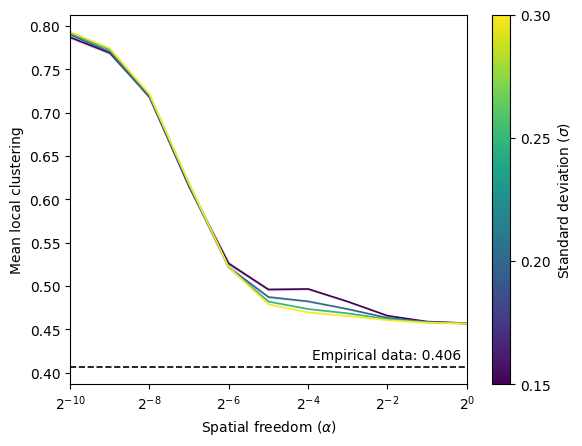

Plotting std vs alpha


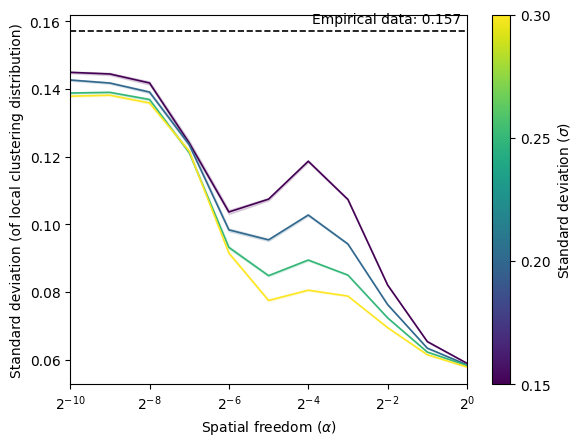

Plotting p10 vs alpha


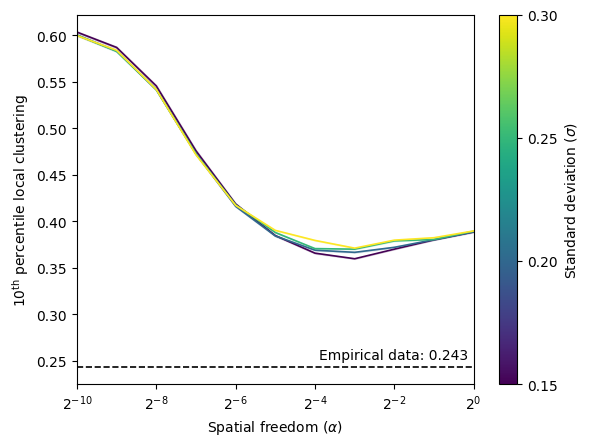

Plotting p25 vs alpha


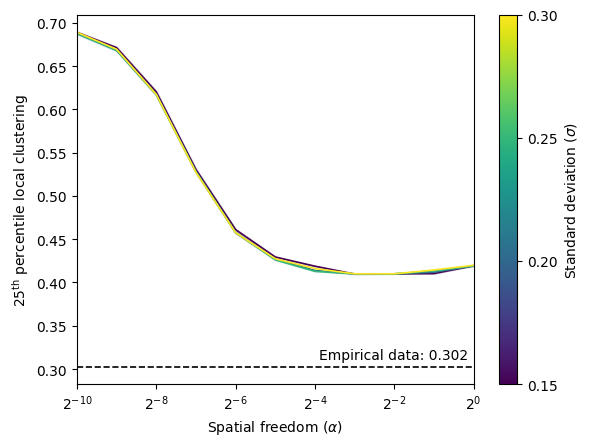

Plotting median vs alpha


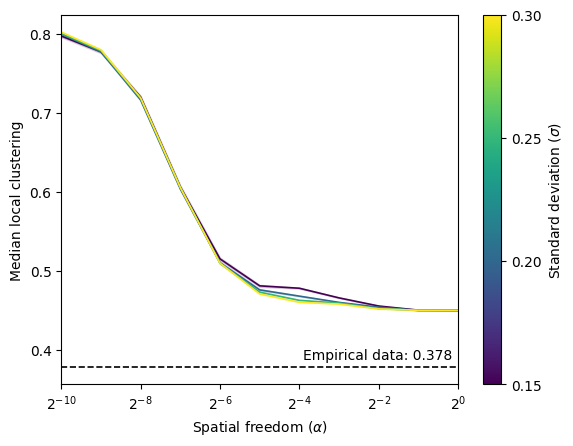

Plotting p75 vs alpha


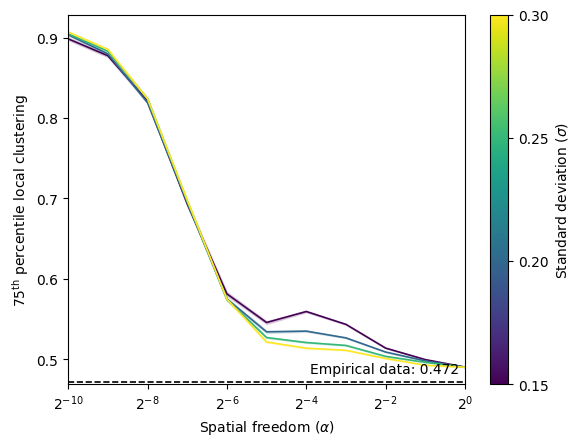

Plotting p90 vs alpha


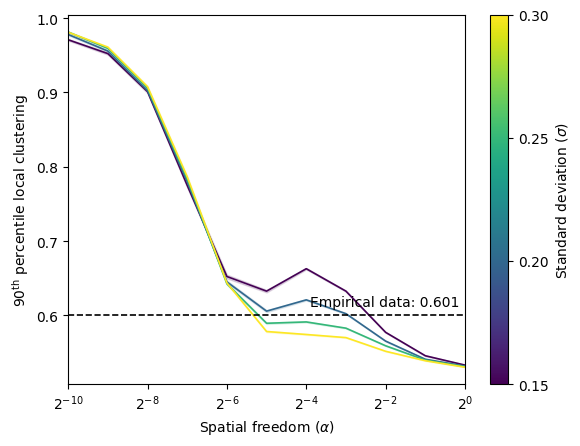

In [49]:
cmap = plt.cm.viridis
norm = Normalize(
    vmin=std_values.min(),
    vmax=std_values.max(),
)

tick_exponents = np.arange(-10, 1, 2)
alpha_ticks = 2.0 ** tick_exponents

for feature, empirical_value, y_label in zip(
    features,
    empirical_values,
    y_labels,
):
    se_col = f"se_{feature}"

    if feature not in df.columns:
        raise KeyError(
            f"Column '{feature}' is missing from the CSV."
        )

    if se_col not in df.columns:
        raise KeyError(
            f"Column '{se_col}' is missing from the CSV."
        )

    print(f"Plotting {feature} vs alpha")

    fig, ax = plt.subplots()

    for std in std_values:
        sub = (
            df[df[std_col] == std]
            .sort_values(alpha_col)
        )

        alphas = sub[alpha_col].to_numpy(dtype=float)
        values = sub[feature].to_numpy(dtype=float)
        ses = sub[se_col].to_numpy(dtype=float)

        color = cmap(norm(std))

        lower = values - ses
        upper = values + ses

        # Required because the y-axis is logarithmic.
        valid_line = (
            np.isfinite(alphas)
            & np.isfinite(values)
            & (alphas > 0)
            & (values > 0)
        )

        ax.plot(
            alphas[valid_line],
            values[valid_line],
            color=color,
            linewidth=1.2,
        )

        # fill_between does not support non-positive values on a log axis.
        lower[lower <= 0] = np.nan
        upper[upper <= 0] = np.nan

        ax.fill_between(
            alphas,
            lower,
            upper,
            color=color,
            alpha=0.15,
        )

    sm = cm.ScalarMappable(
        cmap=cmap,
        norm=norm,
    )
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label(r"Standard deviation ($\sigma$)")
    cbar.set_ticks(std_values)
    cbar.set_ticklabels([
        f"{std:.2f}"
        for std in std_values
    ])

    # Base-2 logarithmic alpha axis.
    ax.set_xscale("log", base=2)
    ax.set_xlim(2**-10, 1)
    ax.set_xticks(alpha_ticks)
    ax.set_xticklabels([
        rf"$2^{{{exponent}}}$"
        for exponent in tick_exponents
    ])

    # Empirical reference.
    ax.axhline(
        empirical_value,
        color="black",
        linestyle="--",
        linewidth=1.2,
    )

    ax.annotate(
        f"Empirical data: {empirical_value:g}",
        xy=(1, empirical_value),
        xytext=(-4, 4),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=10,
    )

    ax.set_xlabel(r"Spatial freedom ($\alpha$)")
    ax.set_ylabel(y_label)

    fig.savefig(
        f"fitting_clustering_{feature}_vs_alpha_by_std_100.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)